In [2]:
# Perform imports and load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import nltk
from nltk.corpus import stopwords

# Download required NLTK data
nltk.download('stopwords')

# Load the dataset
df = pd.read_csv("smsspamcollection.csv", encoding="ISO-8859-1")
print(df.shape)
df.head()

(5572, 2)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\xx807\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [4]:
# Checking for null values
df.isnull().sum()

v1    0
v2    0
dtype: int64

In [5]:
# Checking Duplicate values
df.duplicated().sum()

np.int64(403)

In [6]:
# Drop Duplicate values
df = df.drop_duplicates()
df.shape

(5169, 2)

In [7]:
 # Checking Duplicate values
df.duplicated().sum()

np.int64(0)

In [8]:
# Drop Duplicate values
df = df.drop_duplicates()
df.shape

(5169, 2)

In [9]:
# renaming the columns
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
df.describe()

,label,message
count,5169,5169
unique,2,5169
top,ham,"Go until jurong point, crazy.. Available only ..."
freq,4516,1


In [11]:
df.groupby("label").describe()

message                                                               
        count unique                                                top freq
label                                                                       
ham      4516   4516  Go until jurong point, crazy.. Available only ...    1
spam      653    653  Free entry in 2 a wkly comp to win FA Cup fina...    1

In [12]:
# convert label to a numerical variable
df['label_num'] = df.label.map({'ham':0, 'spam':1})
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [13]:
df['message_len'] = df.message.apply(len)
df.head()

,label,message,label_num,message_len
0,ham,"Go until jurong point, crazy.. Available only ...",0,111
1,ham,Ok lar... Joking wif u oni...,0,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155
3,ham,U dun say so early hor... U c already then say...,0,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61


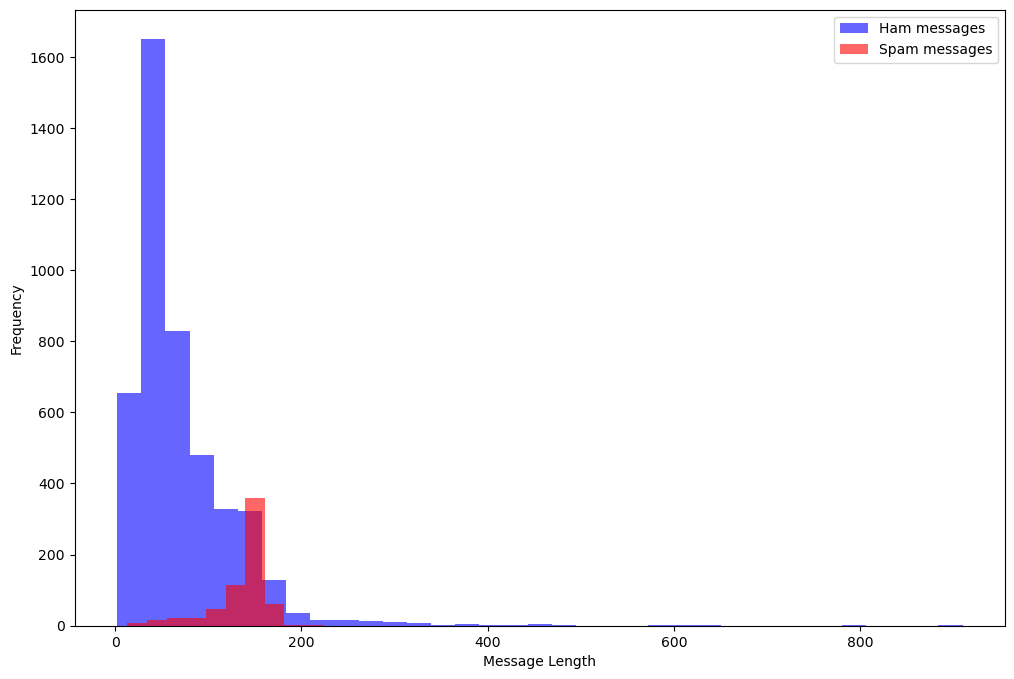

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
df[df.label=='ham'].message_len.plot(bins=35, kind='hist', color='blue', label='Ham messages', alpha=0.6)
df[df.label=='spam'].message_len.plot(kind='hist', color='red', label='Spam messages', alpha=0.6)
plt.legend()
plt.xlabel("Message Length")
plt.show()

In [15]:
df[df.label=='ham'].describe()

,label_num,message_len
count,4516.0,4516.000000
mean,0.0,70.459256
std,0.0,56.358207
min,0.0,2.000000
25%,0.0,34.000000
50%,0.0,52.000000
75%,0.0,90.000000
max,0.0,910.000000


In [16]:
df[df.label=='spam'].describe()

,label_num,message_len
count,653.0,653.000000
mean,1.0,137.891271
std,0.0,30.137753
min,1.0,13.000000
25%,1.0,132.000000
50%,1.0,149.000000
75%,1.0,157.000000
max,1.0,224.000000


In [17]:
# import library
import re
import string
import nltk
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
more_stopwords = ['u', 'im', 'c']
stop_words = stop_words + more_stopwords
stemmer = nltk.SnowballStemmer('english')

def preprocess(text):
    text = text.lower() # Convert text to lowercase
    text = re.sub(r'\[.*?\]', '', text) # Remove text within square brackets
    text = re.sub(r'http\S+\s*\S+', '', text) # Remove URLs starting with http
    text = re.sub(r'www\.\S+', '', text) # Remove URLs starting with www
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    text = re.sub(r'\b\w*\d\w*\b', '', text) # Remove words containing numbers
    text = ' '.join(word for word in text.split() if word not in stop_words) #remove stopwords
    text = ' '.join(stemmer.stem(word) for word in text.split()) #stemming
    return text

df['message_clean'] = df['message'].apply(preprocess)
df.head(20)

,label,message,label_num,message_len,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,0,29,ok lar joke wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,free entri wkli comp win fa cup final tkts may...
3,ham,U dun say so early hor... U c already then say...,0,49,dun say earli hor alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,nah dont think goe usf live around though
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1,148,freemsg hey darl week word back id like fun st...
6,ham,Even my brother is not like to speak with me. ...,0,77,even brother like speak treat like aid patent
7,ham,As per your request 'Melle Melle (Oru Minnamin...,0,160,per request mell mell oru minnaminungint nurun...
8,spam,WINNER!! As a valued network customer you have...,1,158,winner valu network custom select receivea pri...
9,spam,Had your mobile 11 months or more? U R entitle...,1,154,mobil month r entitl updat latest colour mobil...


In [18]:
print(df['message_clean'][304])

sms ac blind date aberdeen unit kingdom check blind date send hide


In [19]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

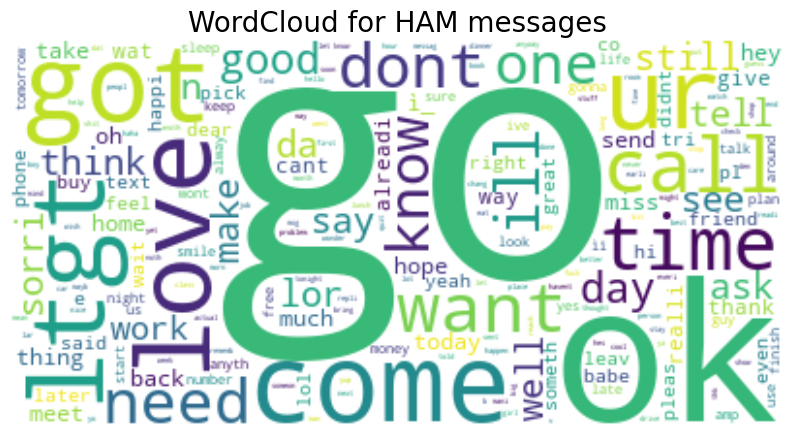

In [21]:
# Create a WordCloud object for HAM messages
wc = WordCloud(
    background_color='white',
    max_words=200,
    contour_color='steelblue',
    contour_width=2,
)

# Generate the WordCloud using text data for HAM messages
ham_text = ' '.join(text for text in df.loc[df['label'] == 'ham', 'message_clean'])
wc.generate(ham_text)

# Visualize the WordCloud
plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.title('WordCloud for HAM messages', fontsize=20)
plt.axis('off')
plt.show()

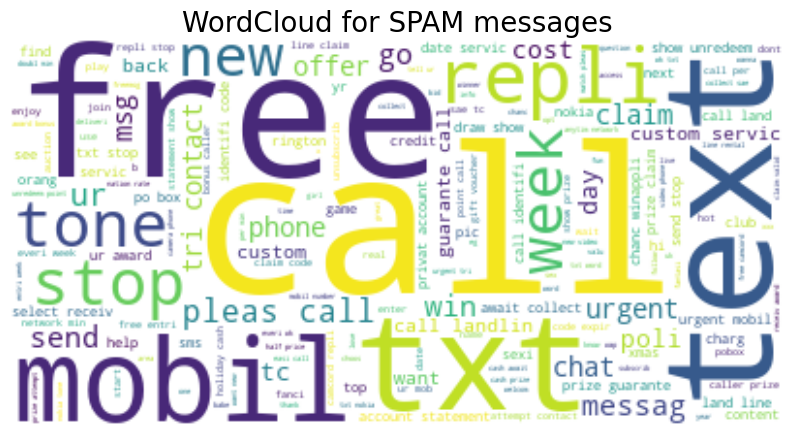

In [22]:
# Create a WordCloud object for SPAM messages
wc = WordCloud(
    background_color='white',
    max_words=200,
    contour_color='steelblue',
    contour_width=2,
)

# Generate the WordCloud using text data for SPAM messages
spam_text = ' '.join(text for text in df.loc[df['label'] == 'spam', 'message_clean'])
wc.generate(spam_text)

# Visualize the WordCloud
plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.title('WordCloud for SPAM messages', fontsize=20)
plt.axis('off')
plt.show()

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer()

X = tfidf_vec.fit_transform(df['message_clean'])
y = df['label']

print("Feature matrix shape:", X.shape)

Feature matrix shape: (5169, 6731)


In [24]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Split data into train & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Naive Bayes
nb_clf = MultinomialNB().fit(X_train, y_train)

# SVM
svm_clf = SVC(kernel="linear").fit(X_train, y_train)

print("Models trained successfully!")

Models trained successfully!


In [25]:
# Performance metrics comparison
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

# Naive Bayes
nb_predicted = nb_clf.predict(X_test)
nb_report = classification_report(y_test, nb_predicted)

# Calculate error rate for Naive Bayes
nb_error_rate = 1 - accuracy_score(y_test, nb_predicted)
nb_cm = confusion_matrix(y_test, nb_predicted)

print("=" * 50)
print("NAIVE BAYES CLASSIFIER")
print("=" * 50)
print("Classification Report:")
print(nb_report)
print("\nConfusion Matrix:")
print(nb_cm)
print(f"\nError Rate: {nb_error_rate:.4f}")

NAIVE BAYES CLASSIFIER
Classification Report:
              precision    recall  f1-score   support

         ham       0.95      1.00      0.97      1107
        spam       1.00      0.67      0.80       186

    accuracy                           0.95      1293
   macro avg       0.97      0.83      0.89      1293
weighted avg       0.95      0.95      0.95      1293


Confusion Matrix:
[[1107    0]
 [  62  124]]

Error Rate: 0.0480


In [26]:
# SVM
svm_predicted = svm_clf.predict(X_test)
svm_report = classification_report(y_test, svm_predicted)

# Calculate error rate for SVM
svm_error_rate = 1 - accuracy_score(y_test, svm_predicted)
svm_cm = confusion_matrix(y_test, svm_predicted)

print("=" * 50)
print("SVM CLASSIFIER")
print("=" * 50)
print("Classification Report:")
print(svm_report)
print("\nConfusion Matrix:")
print(svm_cm)
print(f"\nError Rate: {svm_error_rate:.4f}")

SVM CLASSIFIER
Classification Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1107
        spam       0.99      0.85      0.92       186

    accuracy                           0.98      1293
   macro avg       0.98      0.93      0.95      1293
weighted avg       0.98      0.98      0.98      1293


Confusion Matrix:
[[1105    2]
 [  27  159]]

Error Rate: 0.0224


In [27]:
# SVM
svm_predicted = svm_clf.predict(X_test)
svm_report = classification_report(y_test, svm_predicted)

# Calculate error rate for SVM
svm_error_rate = 1 - accuracy_score(y_test, svm_predicted)
svm_cm = confusion_matrix(y_test, svm_predicted)

print("=" * 50)
print("SVM CLASSIFIER")
print("=" * 50)
print("Classification Report:")
print(svm_report)
print("\nConfusion Matrix:")
print(svm_cm)
print(f"\nError Rate: {svm_error_rate:.4f}")

SVM CLASSIFIER
Classification Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1107
        spam       0.99      0.85      0.92       186

    accuracy                           0.98      1293
   macro avg       0.98      0.93      0.95      1293
weighted avg       0.98      0.98      0.98      1293


Confusion Matrix:
[[1105    2]
 [  27  159]]

Error Rate: 0.0224
